In [1]:
# Imports
from dataclasses import dataclass
import random
import numpy as np
import csv
from deap.tools import cxOnePoint, cxTwoPoints
import time
import copy
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from deap import base, creator, tools, algorithms

random.seed(42)

In [2]:
# A gene contains 2 attributes : the food item's name and the number of servings of this item
@dataclass
class Gene:
    food_item_name: str
    serving: int

In [3]:
# We make a list representing all the meals we have in 1 chromosome
Meals = ["Breakfast", "Snack 1", "Lunch", "Snack 2", "Dinner"]
# We make a list representing all the food groups we have in 1 meal
Food_Groups = ["Vegetables", "Fruits", "Grains", "Protein", "Dairy", "Fats and Oils"]

In [4]:
# Load dataset
def load_food_data(csv_path):
    food_data = {}
    meal_flags = {}

    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            group = row['Category']
            food = row['Food Item']

            if group not in food_data:
                food_data[group] = {}

            # Safely convert numeric columns, use 0 if empty
            def safe_float(x):
                try:
                    return float(x)
                except (ValueError, TypeError):
                    return 0.0

            food_data[group][food] = {
                'p': safe_float(row['Protein (g)']),
                'f': safe_float(row['Fats (g)']),
                'c': safe_float(row['Carbohydrates (g)']),
                'cal': safe_float(row['Calories (kcal)']),
                'pref': safe_float(row['User Preference'])
            }

            # Safely convert meal flags (0 if empty)
            def safe_int(x):
                try:
                    return int(x)
                except (ValueError, TypeError):
                    return 0

            meal_flags[food] = {
                'Breakfast': safe_int(row['Breakfast']),
                'Snack 1': safe_int(row['Snack 1']),
                'Lunch': safe_int(row['Lunch']),
                'Snack 2': safe_int(row['Snack 2']),
                'Dinner': safe_int(row['Dinner'])
            }

    return food_data, meal_flags


FOOD_DATA, MEAL_FLAGS = load_food_data("Processed_Bahrain_Food_Dataset.csv")

In [5]:
# Dictionary that contains all the saudi guideline's servings
SERVING_GUIDELINES_BY_KCAL = {
    1200: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 0},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1300: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1400: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 0}
    },

    1500: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 0, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1600: {
        "Breakfast": {"Grains": 2, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1700: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 1, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    1800: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    1900: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 1, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    },

    2000: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 2, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 0}
    },

    2200: {
        "Breakfast": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 1, "Fruits": 0, "Fats and Oils": 1},
        "Snack 1": {"Grains": 1, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Lunch": {"Grains": 3, "Dairy": 1, "Protein": 3, "Vegetables": 2, "Fruits": 0, "Fats and Oils": 1},
        "Snack 2": {"Grains": 2, "Dairy": 0, "Protein": 0, "Vegetables": 0, "Fruits": 1, "Fats and Oils": 0},
        "Dinner": {"Grains": 2, "Dairy": 0, "Protein": 2, "Vegetables": 1, "Fruits": 1, "Fats and Oils": 1}
    }
}

In [6]:
# DEAP Configuration
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()


# Initialize Population
def create_individual():
    # Initializes 30 genes following 1600 kcal
    genes = []
    for meal in Meals:
        for group in Food_Groups:
            # Get the fixed serving count for this meal/group
            serving_count = SERVING_GUIDELINES_BY_KCAL[TARGET_KCAL][meal][group]

            # Filter foods allowed for this meal
            allowed_foods = [
                food for food in FOOD_DATA[group].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if not allowed_foods:
                allowed_foods = list(FOOD_DATA[group].keys())  # fallback

            # Randomly select food from allowed foods
            food_name = random.choice(allowed_foods)

            # Create gene with guideline serving count
            genes.append(Gene(food_item_name=food_name, serving=serving_count))

    return creator.Individual(genes)


toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# Fitness Function
def evaluate_meal_plan(individual):
    total_p = 0.0  # Protein grams
    total_f = 0.0  # Fat grams
    total_c = 0.0  # Carbohydrates grams
    total_cal = 0.0  # Total Calories
    total_pref = 0.0  # Total user preference

    # Sum up all grams and calories based on food item and serving count
    for gene in individual:
        group_name = None
        # Find which group this food belongs to
        for group, foods in FOOD_DATA.items():
            if gene.food_item_name in foods:
                group_name = group
                break

        if group_name:
            stats = FOOD_DATA[group_name][gene.food_item_name]
            total_p += stats['p'] * gene.serving
            total_f += stats['f'] * gene.serving
            total_c += stats['c'] * gene.serving
            total_cal += stats['cal'] * gene.serving
            if gene.serving > 0:
                total_pref += stats['pref']
    # Calculate actual macro percentages (p_c, p_p, p_f)
    g_total = total_p + total_f + total_c
    if g_total == 0: return 0,  # Avoid division by zero

    p_p = total_p / g_total
    p_f = total_f / g_total
    p_c = total_c / g_total

    # Target Ratios (The AMDR values)
    r_p, r_f, r_c = 0.20, 0.25, 0.55

    # Objective function: J_macro (Squared Error)
    j_macro = (p_c - r_c) ** 2 + (p_p - r_p) ** 2 + (p_f - r_f) ** 2

    # Total calorie constraint (J_cal)
    r = (total_cal - TARGET_KCAL) / TARGET_KCAL
    j_cal = min(1, r ** 2)

    # Variety constraint (J_var)
    N = sum(1 for gene in individual if
            gene.serving > 0)  # total number of food items in the chromosome (N is taken from the report)
    # count food appearance
    food_appearance = {}
    for gene in individual:
        if gene.serving > 0:
            food_appearance[gene.food_item_name] = food_appearance.get(gene.food_item_name, 0) + 1
    # Calculate the penalty for variety
    j_var = 0
    for food_name, count in food_appearance.items():
        # we penalize if the food item appears more than once
        if count > 1:
            j_var += max(0, count - 1) ** 2
    # Normalize the penalty
    j_var = j_var / ((N - 1) ** 2)

    # User preference constraint (J_pref)
    j_pref = total_pref / N

    # Calculate the score
    w_macro, w_cal, w_var, w_pref = 0.25, 0.25, 0.25, 0.25
    score = w_macro * j_macro + w_var * j_var + w_cal * j_cal + w_pref * j_pref

    # store the penalties to print later
    individual.j_var = j_var
    individual.j_macro = j_macro
    individual.j_cal = j_cal
    individual.j_pref = j_pref

    # We want to minimize score, so we return a fitness that increases as score decreases
    return 1 / (1 + score),


# Crossover
def one_cx_meal_plan(parent1, parent2):
    GROUPS = 6
    MEALS = 5

    m1 = random.randrange(1, MEALS)
    cut = m1 * GROUPS
    parent1[cut:], parent2[cut:] = parent2[cut:], parent1[cut:]
    return parent1, parent2


def two_cx_meal_plan(parent1, parent2):
    GROUPS = 6
    MEALS = 5

    # Choose 2 meal cut points
    m1, m2 = sorted(random.sample(range(1, MEALS), 2))
    cut1, cut2 = m1 * GROUPS, m2 * GROUPS

    # Swap full meals
    parent1[cut1:cut2], parent2[cut1:cut2] = parent2[cut1:cut2], parent1[cut1:cut2]

    return parent1, parent2


# Mutation
def mutate_meal_plan(individual):
    mutations_done = 0
    all_indices = list(range(len(individual)))  # List of all possible indices in the chromosome
    random.shuffle(all_indices)  # Shuffle to pick randomly without repeating the same one

    for i in all_indices:
        if mutations_done >= 2:
            break  # Stop once we have mutated 2 genes

        # Check if the serving size is not zero
        if individual[i].serving > 0:
            # Find which group it belongs to (Vegetables, Grains, ...)
            group_name = Food_Groups[i % 6]
            # What meal it belongs to (Breakfast, Snack 1,...)
            meal = Meals[i // 6]

            # Check compatibility
            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys() if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                # Pick a new food name from food group dictionary, but the serving remains the same
                individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1
    return individual,


toolbox.register("evaluate", evaluate_meal_plan)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", cxOnePoint)  # one-point crossover
toolbox.register("mutate", mutate_meal_plan)

In [7]:
# GA Execution Loop
def run_simulation(target_kcal, pop_size, cxpb, mutpb, patience):
    global TARGET_KCAL
    TARGET_KCAL = target_kcal  # tells create_individual which guideline to use

    pop = toolbox.population(n=pop_size)

    hof = tools.HallOfFame(1)  # keeps the absolute best found across all generations

    mu = len(pop)  # number of individuals to select for the next generation
    lambd = 100  # number of children to produce in each generation

    MAX_GEN = 300  # max num no more
    PATIENCE = patience
    EPS = 1e-6  # small new update ignor

    best_so_far = None
    stagnant = 0

    # Statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    for gen in range(MAX_GEN):

        # run ONE generation
        algorithms.eaMuPlusLambda(
            pop, toolbox,
            mu=mu,
            lambda_=lambd,
            cxpb=cxpb,
            mutpb=mutpb,
            ngen=1,
            stats=stats,
            halloffame=hof,
            verbose=False
        )
        hof.update(pop)

        current_best = hof[0].fitness.values[0]

        if best_so_far is None or current_best > best_so_far + EPS:
            best_so_far = current_best
            stagnant = 0
        else:
            stagnant += 1

        if stagnant >= PATIENCE:
            # print(f"\nEarly stopping at generation {gen + 1} (no improvement for {PATIENCE} gens)")
            break

    # print(f"Final Gen {gen + 1} | best={current_best:.8f} | stagnant={stagnant}/{PATIENCE}")
    # print("-" * 50)

    return hof[0].fitness.values[0], gen + 1

In [8]:
# Random Search
def run_random_search(time_budget):
    start_time = time.time()

    best_individual = None
    best_fitness = -float("inf")
    trials = 0

    while (time.time() - start_time) < time_budget:
        ind = create_individual()
        fitness = evaluate_meal_plan(ind)[0]
        trials += 1

        if fitness > best_fitness:
            best_fitness = fitness
            best_individual = ind

    end_time = time.time()
    total_time = end_time - start_time

    return best_individual, best_fitness, trials, total_time

In [9]:
# Local Search
def run_local_search(toolbox, pop_size, time_budget):

    start_time = time.time()

    # 1. Generate initial population
    pop = toolbox.population(n=pop_size)

    # 2. Evaluate population
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    # 3. Pick one random from initial population
    current = toolbox.clone(random.choice(pop))

    trials = 0

    # 4. Local search loop
    while (time.time() - start_time) < time_budget:

        neighbor = toolbox.clone(current)
        neighbor, = mutate_meal_plan(neighbor)

        neighbor.fitness.values = toolbox.evaluate(neighbor)
        trials += 1

        if neighbor.fitness.values[0] > current.fitness.values[0]:
            current = toolbox.clone(neighbor)

    return current, current.fitness.values[0], trials

In [10]:
# Simulated Annealing
def fitness_to_cost(fitness):
    return (1 / fitness) - 1


def get_neighbor(individual):
    new_individual = copy.deepcopy(individual)

    mutations_done = 0
    all_indices = list(range(len(new_individual)))
    random.shuffle(all_indices)

    for i in all_indices:
        if mutations_done >= 2:
            break

        if new_individual[i].serving > 0:
            group_name = Food_Groups[i % 6]
            meal = Meals[i // 6]

            allowed_foods = [
                food for food in FOOD_DATA[group_name].keys()
                if MEAL_FLAGS[food][meal] == 1
            ]
            if allowed_foods:
                new_individual[i].food_item_name = random.choice(allowed_foods)
                mutations_done += 1

    return new_individual


def run_simulated_annealing(toolbox, pop_size,
                            cooling_rate=0.98,
                            iterations_per_temp=200,
                            time_limit=None):

    # Generate population
    current = toolbox.individual()
    current_fitness = evaluate_meal_plan(current)[0]
    current_cost = fitness_to_cost(current_fitness)


    best = copy.deepcopy(current)
    best_fitness = current_fitness

    T = 1.0
    min_temp=0.001
    total_iterations = 0
    start_time = time.time()


    while T > min_temp:
        if time_limit and (time.time() - start_time) >= time_limit:
            break
        for _ in range(iterations_per_temp):

            new = get_neighbor(current)
            new_fitness = evaluate_meal_plan(new)[0]
            new_cost = fitness_to_cost(new_fitness)

            delta = new_cost - current_cost

            if delta <= 0 or random.random() < math.exp(-delta / T):
                current = new
                current_fitness = new_fitness
                current_cost = new_cost

            if current_fitness > best_fitness:
                best = copy.deepcopy(current)
                best_fitness = current_fitness

            total_iterations += 1

        T *= cooling_rate

    return best, best_fitness, total_iterations

In [11]:
def print_meal_plan(individual):
    total_p = total_f = total_c = total_cal = 0.0

    #print(f"\n{'MEAL':<12} | {'GROUP':<14} | {'FOOD ITEM':<25} | {'SERV.':<6} | {'P (g)':<6} | {'F (g)':<6} | {'C (g)':<6} | {'CALS':<6} | {'PREF':<6}")
    #print("-" * 100)

    for i, gene in enumerate(individual):
        meal = Meals[i // 6]
        group = Food_Groups[i % 6]
        stats = FOOD_DATA[group][gene.food_item_name]
        p = stats['p'] * gene.serving
        f = stats['f'] * gene.serving
        c = stats['c'] * gene.serving
        cal = stats['cal'] * gene.serving
        pref = stats['pref'] if gene.serving > 0 else 0
        total_p += p
        total_f += f
        total_c += c
        total_cal += cal

        #print(f"{meal:<12} | {group:<14} | {gene.food_item_name:<25} | {gene.serving:<6} | {p:<6.1f} |{f:<6.1f} | {c:<6.1f} | {cal:<6.1f} | {pref:<6.2f}")

    g_total = total_p + total_f + total_c
    p_p = (total_p / g_total) * 100
    p_f = (total_f / g_total) * 100
    p_c = (total_c / g_total) * 100
    variety = (1 - individual.j_var) * 100
    calories = (total_cal / TARGET_KCAL) * 100
    preference_score = (1 - individual.j_pref) * 100

    print("\n" + "=" * 40)
    print("       DAILY NUTRITION SUMMARY")
    print("=" * 40)
    print(f"Total Energy:   {total_cal:.1f} kcal")
    print(f"Total Weight:   {g_total:.1f} g (Macro Grams)")
    print("-" * 40)
    print(f"Nutrient        | Actual % | Target %")
    print(f"Carbs (c)       | {p_c:>7.1f}% | 55.0%")
    print(f"Protein (p)     | {p_p:>7.1f}% | 20.0%")
    print(f"Fats (f)        | {p_f:>7.1f}% | 25.0%")
    print(f"Meal variety    | {variety:>7.1f}% | 100%")
    print(f"Meal calorie    | {calories:>7.1f}% | 100%")
    print(f"User preference | {preference_score:>7.1f}% | 100%")
    print("=" * 40)

---
## Multi-Dataset Experiment
**Run the cell below once first**, then run any of the 6 case cells individually. Finally, run the **Combined Report** cell at the bottom to generate all charts and the summary CSV.

| Cell | What it does |
|------|--------------|
| **Shared Setup** | Initialises shared storage and defines `run_case()` — **run once** |
| **Case 1–6** | Runs GA + RS + LS + SA for that dataset, stores results — **run individually** |
| **Combined Report** | Prints summary table, plots all charts, exports CSV — **run after cases** |

In [12]:
# ── Shared Setup — run this cell ONCE before running any case below ──────────
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Experiment settings (edit here to change for all cases at once)
EXP_TARGETS = [1200, 1600, 2200]   # kcal targets
N_RUNS      = 10                   # independent runs per algorithm per target
POP_SIZE    = 95
CXPB, MUTPB = 0.55, 0.17
PATIENCE    = 50
ALGOS       = ['GA', 'RS', 'LS', 'SA']
ALGO_COLORS = {'GA': '#4C72B0', 'RS': '#DD8452', 'LS': '#55A868', 'SA': '#C44E52'}

# Shared storage — each case cell writes its results here
all_case_results = {}   # {case_label: {target: {algo: {'fitness': [], 'stats': {}}}}}
all_case_times   = {}   # {case_label: {target: avg_ga_time}}

def _stats(lst):
    return {
        'mean': float(np.mean(lst)),
        'max':  float(np.max(lst)),
        'min':  float(np.min(lst)),
        'std':  float(np.std(lst)),
    }

def run_case(case_label, csv_path):
    """
    Load the dataset at csv_path, run GA x N_RUNS for each target in EXP_TARGETS,
    then run RS / LS / SA with the same time budget, and store everything in
    all_case_results[case_label] and all_case_times[case_label].
    """
    global TARGET_KCAL, FOOD_DATA, MEAL_FLAGS

    print(f"\n{'='*70}")
    print(f"  {case_label}")
    print(f"  Dataset : {csv_path}")
    print(f"{'='*70}")

    FOOD_DATA, MEAL_FLAGS = load_food_data(csv_path)

    case_results = {}
    case_times   = {}

    for target in EXP_TARGETS:
        print(f"\n  ── Target {target} kcal ──")
        TARGET_KCAL = target

        # ── GA ────────────────────────────────────────────────────────────────
        ga_fitness_list, ga_runtime_list = [], []
        print(f"    {'Run':<5} {'StopGen':<10} {'GA Fit':<12} {'Time (s)':<10}")
        for run in range(1, N_RUNS + 1):
            t0 = time.time()
            ga_fit, stop_gen = run_simulation(
                target, pop_size=POP_SIZE, cxpb=CXPB, mutpb=MUTPB, patience=PATIENCE
            )
            rt = time.time() - t0
            ga_fitness_list.append(ga_fit)
            ga_runtime_list.append(rt)
            print(f"    {run:<5} {stop_gen:<10} {ga_fit:<12.6f} {rt:<10.4f}")

        avg_ga_time        = float(np.mean(ga_runtime_list))
        case_times[target] = avg_ga_time
        ga_stats           = _stats(ga_fitness_list)
        print(f"    GA  avg={ga_stats['mean']:.6f}  max={ga_stats['max']:.6f}  "
              f"min={ga_stats['min']:.6f}  std={ga_stats['std']:.6f}  "
              f"avg_time={avg_ga_time:.4f}s")

        # ── RS / LS / SA (equal time budget = GA avg runtime) ─────────────────
        rs_fitness_list, ls_fitness_list, sa_fitness_list = [], [], []
        budget = avg_ga_time
        print(f"\n    Time budget = {budget:.4f}s  (= GA avg runtime)")
        print(f"    {'Run':<5} {'RS Fit':<12} {'LS Fit':<12} {'SA Fit':<12}")
        for run in range(1, N_RUNS + 1):
            _, rs_fit, _, _ = run_random_search(budget)
            _, ls_fit, _    = run_local_search(toolbox, POP_SIZE, budget)
            _, sa_fit, _    = run_simulated_annealing(toolbox, POP_SIZE, time_limit=budget)
            rs_fitness_list.append(rs_fit)
            ls_fitness_list.append(ls_fit)
            sa_fitness_list.append(sa_fit)
            print(f"    {run:<5} {rs_fit:<12.6f} {ls_fit:<12.6f} {sa_fit:<12.6f}")

        for algo, lst in [('RS', rs_fitness_list), ('LS', ls_fitness_list), ('SA', sa_fitness_list)]:
            s = _stats(lst)
            print(f"    {algo}  avg={s['mean']:.6f}  max={s['max']:.6f}  "
                  f"min={s['min']:.6f}  std={s['std']:.6f}")

        case_results[target] = {
            'GA': {'fitness': ga_fitness_list, 'stats': ga_stats, 'avg_time': avg_ga_time},
            'RS': {'fitness': rs_fitness_list, 'stats': _stats(rs_fitness_list)},
            'LS': {'fitness': ls_fitness_list, 'stats': _stats(ls_fitness_list)},
            'SA': {'fitness': sa_fitness_list, 'stats': _stats(sa_fitness_list)},
        }

    all_case_results[case_label] = case_results
    all_case_times[case_label]   = case_times
    print(f"\n  ✓ Done — results stored under key: '{case_label}'")

print('Shared setup ready. Run any Case cell below.')


Shared setup ready. Run any Case cell below.


In [13]:
# ── Case 1: Case 1 - 1000 rows (Original + Synthetic) ──────────────────────────────────────────────────
run_case(
    case_label = 'Case 1 - 1000 rows (Original + Synthetic)',
    csv_path   = 'case1_1000_orig_synth.csv'
)



  Case 1 - 1000 rows (Original + Synthetic)
  Dataset : case1_1000_orig_synth.csv

  ── Target 1200 kcal ──
    Run   StopGen    GA Fit       Time (s)  
    1     183        0.989629     3.9310    
    2     219        0.991863     4.4672    
    3     147        0.994849     3.0883    
    4     106        0.992479     2.1257    
    5     193        0.990763     3.8957    
    6     221        0.986354     4.3727    
    7     183        0.994815     3.6132    
    8     218        0.994941     4.3474    
    9     117        0.990135     2.2816    
    10    229        0.994028     4.4078    
    GA  avg=0.991986  max=0.994941  min=0.986354  std=0.002675  avg_time=3.6531s

    Time budget = 3.6531s  (= GA avg runtime)
    Run   RS Fit       LS Fit       SA Fit      
    1     0.933438     0.991083     0.931230    
    2     0.936261     0.986686     0.923254    
    3     0.925496     0.991118     0.941180    
    4     0.925148     0.995508     0.944656    
    5     0.933515     

In [14]:
# ── Case 2: Case 2 - 1000 rows (Original + Duplicates) ──────────────────────────────────────────────────
run_case(
    case_label = 'Case 2 - 1000 rows (Original + Duplicates)',
    csv_path   = 'case2_1000_orig_dup.csv'
)



  Case 2 - 1000 rows (Original + Duplicates)
  Dataset : case2_1000_orig_dup.csv

  ── Target 1200 kcal ──
    Run   StopGen    GA Fit       Time (s)  
    1     300        0.966525     5.9496    
    2     163        0.972286     3.3236    
    3     190        0.970366     3.8592    
    4     125        0.965263     2.4603    
    5     105        0.967811     2.0785    
    6     117        0.965016     2.2952    
    7     124        0.972291     2.4913    
    8     169        0.972052     3.2481    
    9     163        0.967806     3.2364    
    10    190        0.959736     4.1595    
    GA  avg=0.967915  max=0.972291  min=0.959736  std=0.003817  avg_time=3.3102s

    Time budget = 3.3102s  (= GA avg runtime)
    Run   RS Fit       LS Fit       SA Fit      
    1     0.920258     0.972052     0.931785    
    2     0.921714     0.959255     0.913553    
    3     0.922489     0.965579     0.935332    
    4     0.918325     0.963173     0.915632    
    5     0.929678     0

In [15]:
# ── Case 3: Case 3 - 5000 rows (Original + Synthetic) ──────────────────────────────────────────────────
run_case(
    case_label = 'Case 3 - 5000 rows (Original + Synthetic)',
    csv_path   = 'case3_5000_orig_synth.csv'
)



  Case 3 - 5000 rows (Original + Synthetic)
  Dataset : case3_5000_orig_synth.csv

  ── Target 1200 kcal ──
    Run   StopGen    GA Fit       Time (s)  
    1     170        0.995418     4.3585    
    2     271        0.986687     6.9835    
    3     94         0.989984     2.5009    
    4     300        0.986754     7.6959    
    5     104        0.990826     2.7438    
    6     185        0.990972     4.7507    
    7     300        0.995436     7.4859    
    8     108        0.994335     2.9639    
    9     259        0.990959     6.6335    
    10    220        0.991026     5.2668    
    GA  avg=0.991240  max=0.995436  min=0.986687  std=0.002957  avg_time=5.1383s

    Time budget = 5.1383s  (= GA avg runtime)
    Run   RS Fit       LS Fit       SA Fit      
    1     0.914800     0.982446     0.926134    
    2     0.929723     0.986775     0.938073    
    3     0.923947     0.982430     0.938787    
    4     0.932630     0.991140     0.930244    
    5     0.916382     

In [16]:
# ── Case 4: Case 4 - 5000 rows (Original + Duplicates) ──────────────────────────────────────────────────
run_case(
    case_label = 'Case 4 - 5000 rows (Original + Duplicates)',
    csv_path   = 'case4_5000_orig_dup.csv'
)



  Case 4 - 5000 rows (Original + Duplicates)
  Dataset : case4_5000_orig_dup.csv

  ── Target 1200 kcal ──
    Run   StopGen    GA Fit       Time (s)  
    1     101        0.962946     2.5493    
    2     162        0.958266     4.0859    
    3     123        0.958015     3.0836    
    4     163        0.966520     4.1226    
    5     159        0.965008     4.0639    
    6     101        0.965395     2.5641    
    7     118        0.963465     3.2335    
    8     116        0.963499     4.3025    
    9     128        0.967136     4.9491    
    10    196        0.964355     7.4389    
    GA  avg=0.963461  max=0.967136  min=0.958015  std=0.002945  avg_time=4.0393s

    Time budget = 4.0393s  (= GA avg runtime)
    Run   RS Fit       LS Fit       SA Fit      
    1     0.917294     0.953164     0.915045    
    2     0.923725     0.955185     0.913198    
    3     0.916985     0.947521     0.908992    
    4     0.921815     0.950869     0.910580    
    5     0.932152     0

In [17]:
# ── Case 5: Case 5 - 1000 rows (Original + Synthetic + Dupl.) ──────────────────────────────────────────────────
run_case(
    case_label = 'Case 5 - 1000 rows (Original + Synthetic + Dupl.)',
    csv_path   = 'case5_1000_orig_synth_dup.csv'
)



  Case 5 - 1000 rows (Original + Synthetic + Dupl.)
  Dataset : case5_1000_orig_synth_dup.csv

  ── Target 1200 kcal ──
    Run   StopGen    GA Fit       Time (s)  
    1     199        0.988094     7.1530    
    2     255        0.979552     8.7544    
    3     95         0.981253     3.7283    
    4     78         0.982272     3.2389    
    5     178        0.988438     7.0254    
    6     135        0.988746     5.2577    
    7     152        0.988527     5.9783    
    8     218        0.975646     8.4941    
    9     136        0.985730     5.3810    
    10    149        0.989890     5.5887    
    GA  avg=0.984815  max=0.989890  min=0.975646  std=0.004589  avg_time=6.0600s

    Time budget = 6.0600s  (= GA avg runtime)
    Run   RS Fit       LS Fit       SA Fit      
    1     0.930901     0.980642     0.949576    
    2     0.953989     0.989327     0.938731    
    3     0.930131     0.972110     0.918035    
    4     0.932684     0.985391     0.936569    
    5     0

In [18]:
# ── Case 6: Case 6 - 5000 rows (Original + Synthetic + Dupl.) ──────────────────────────────────────────────────
run_case(
    case_label = 'Case 6 - 5000 rows (Original + Synthetic + Dupl.)',
    csv_path   = 'case6_5000_orig_synth_dup.csv'
)



  Case 6 - 5000 rows (Original + Synthetic + Dupl.)
  Dataset : case6_5000_orig_synth_dup.csv

  ── Target 1200 kcal ──
    Run   StopGen    GA Fit       Time (s)  
    1     109        0.986087     3.1132    
    2     168        0.980341     4.6827    
    3     146        0.985536     4.1928    
    4     300        0.989397     8.1846    
    5     87         0.986285     2.5221    
    6     138        0.985785     3.9161    
    7     176        0.995422     4.9495    
    8     300        0.991121     8.4148    
    9     211        0.995223     5.8634    
    10    112        0.980649     3.2129    
    GA  avg=0.987585  max=0.995422  min=0.980341  std=0.004975  avg_time=4.9052s

    Time budget = 4.9052s  (= GA avg runtime)
    Run   RS Fit       LS Fit       SA Fit      
    1     0.921318     0.994728     0.926053    
    2     0.930645     0.991126     0.929323    
    3     0.934269     0.991088     0.932301    
    4     0.926116     0.978140     0.920413    
    5     0

Building report for 6 case(s) ...


   SUMMARY REPORT

──────────────────────────────────────────────────────────────────────────────────
  Case 1 - 1000 rows (Original + Synthetic)
──────────────────────────────────────────────────────────────────────────────────
  Target     Algo         Mean        Max        Min        Std    GA Time
  ------------------------------------------------------------------------
  1200 kcal  GA       0.991986   0.994941   0.986354   0.002675     3.653s
  1200 kcal  RS       0.929930   0.944329   0.918955   0.006977           
  1200 kcal  LS       0.988899   0.995508   0.982171   0.004517           
  1200 kcal  SA       0.933667   0.944656   0.923254   0.007397           

  1600 kcal  GA       0.990369   0.996449   0.979517   0.006140     3.670s
  1600 kcal  RS       0.925570   0.935699   0.917751   0.006035           
  1600 kcal  LS       0.984950   0.993080   0.976245   0.005043           
  1600 kcal  SA       0.928912   0.940827   0.916955   0.00

C:\Users\DSC\AppData\Local\Temp\ipykernel_19324\293901595.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=ALGOS, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19324\293901595.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=ALGOS, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19324\293901595.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=ALGOS, patch_artist=True)
C:\Users\DSC\AppData\Local\Temp\ipykernel_19324\293901595.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of 

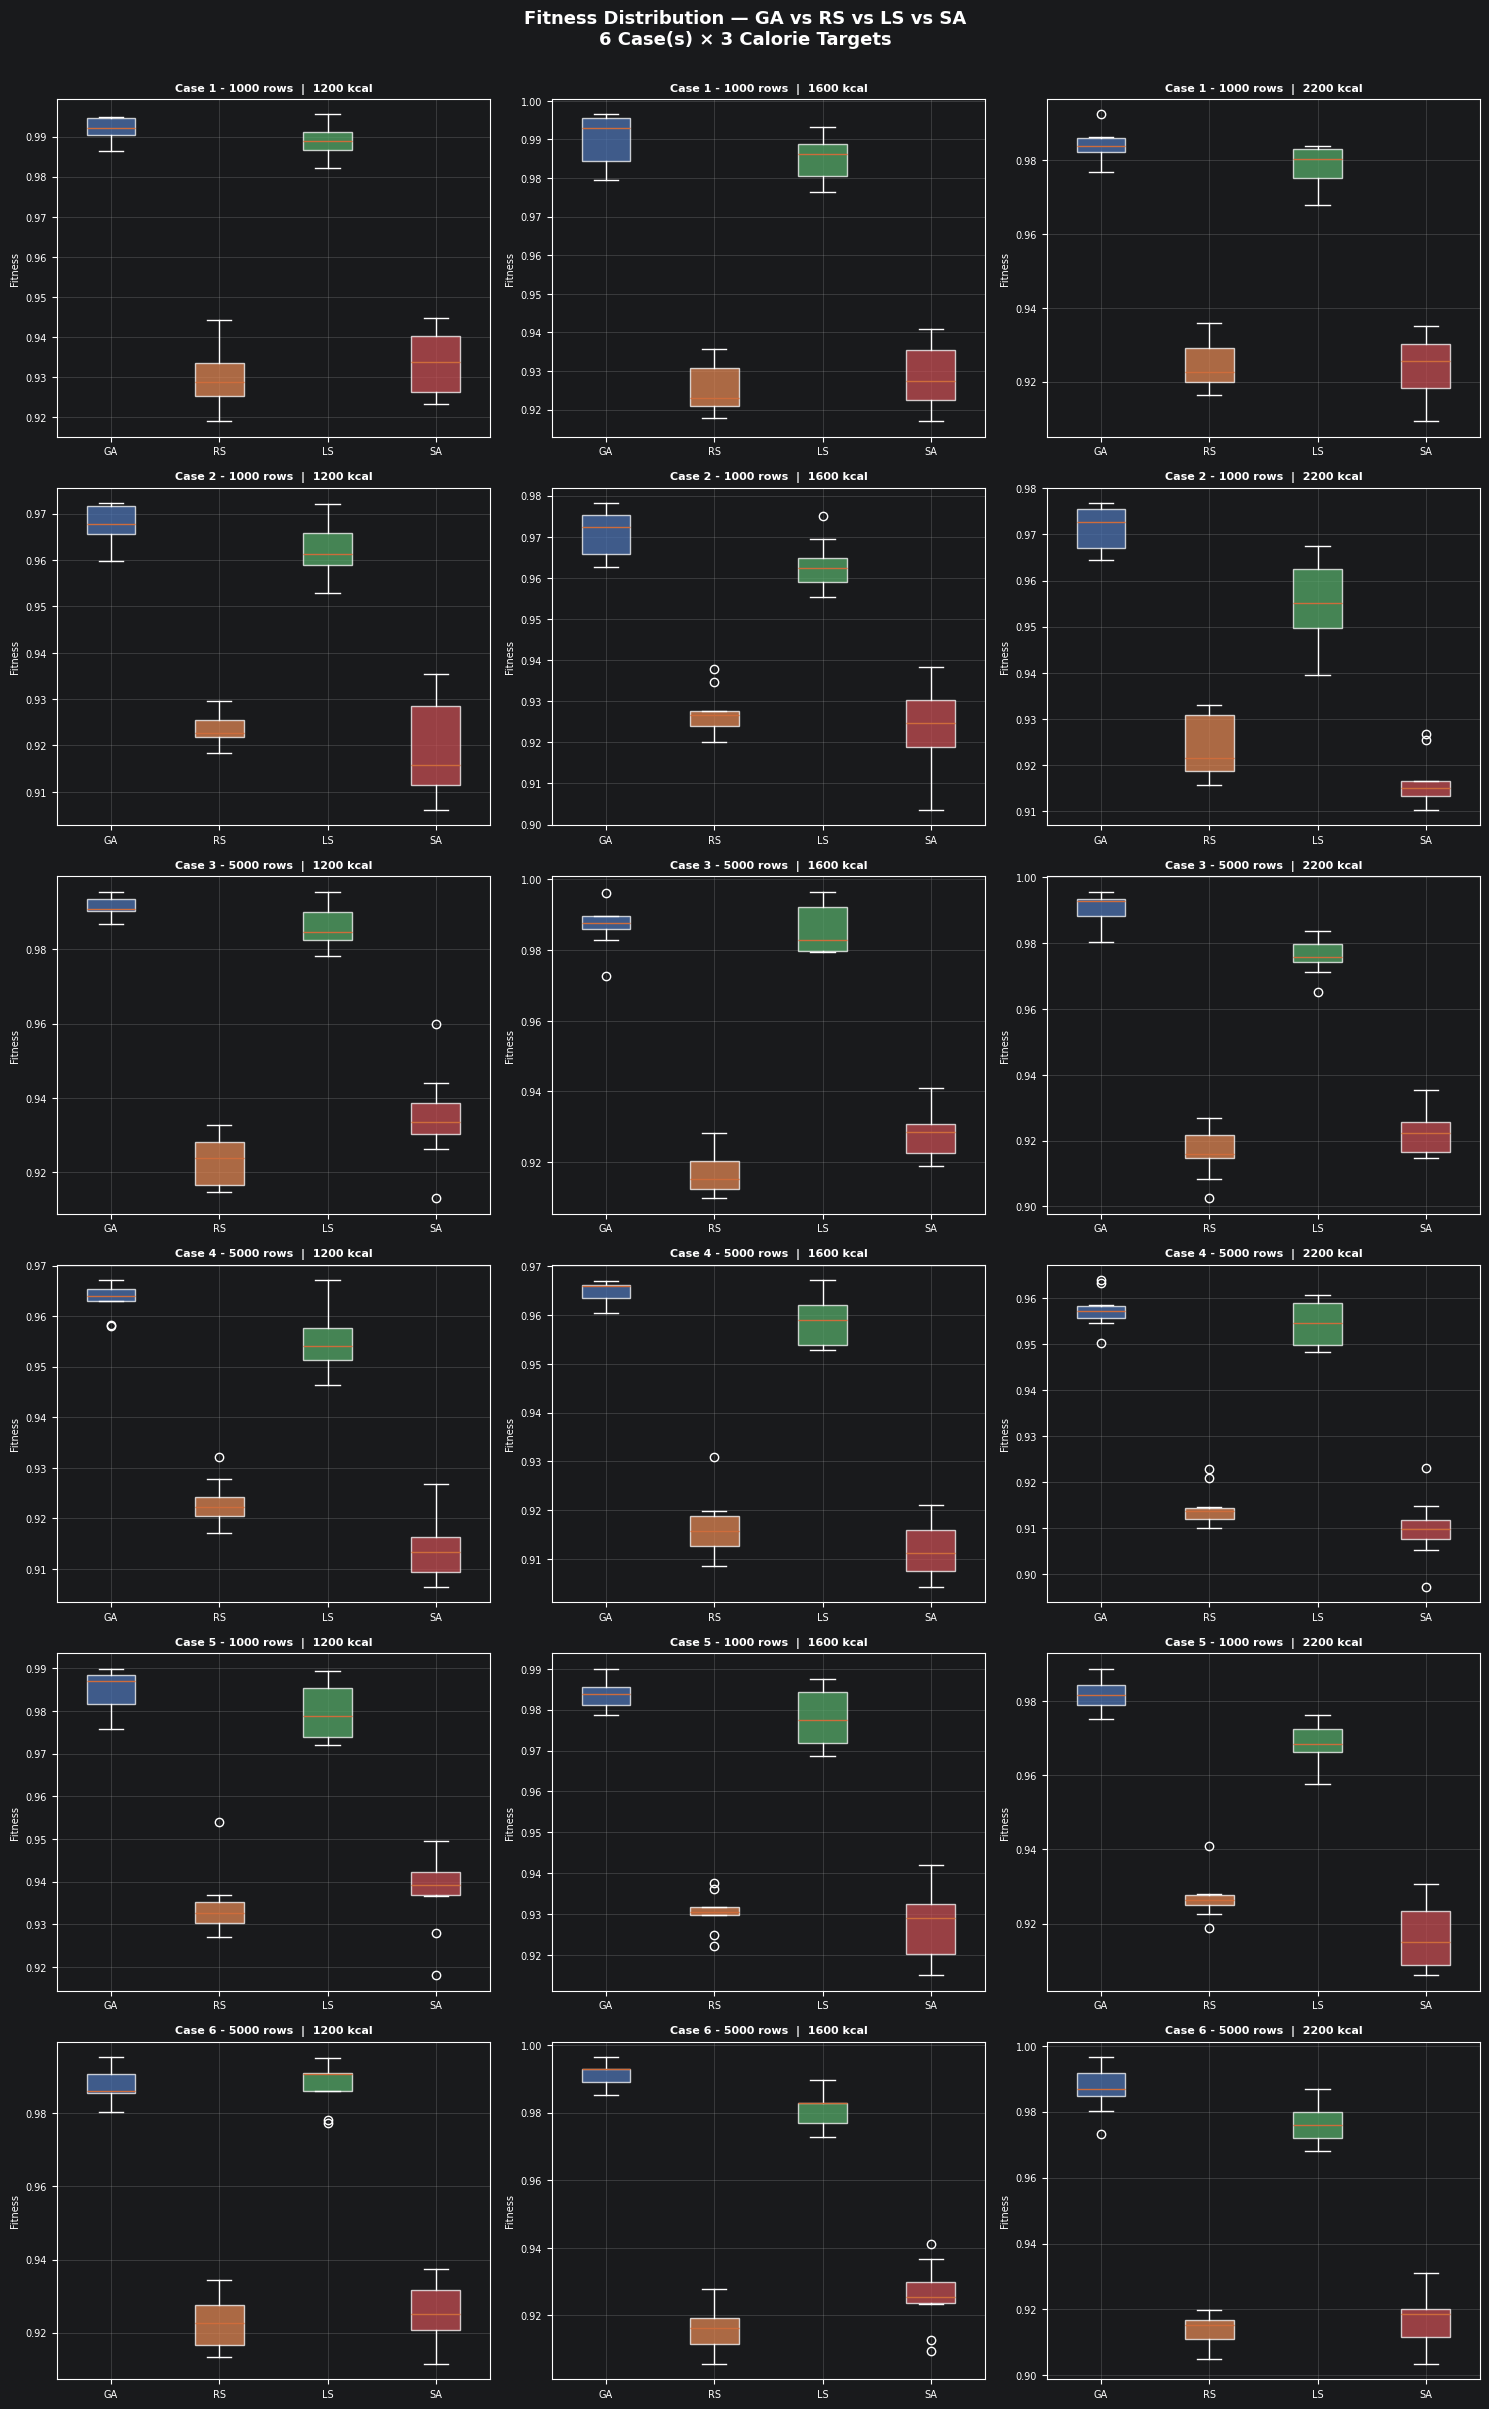

Saved: multi_case_boxplots.png


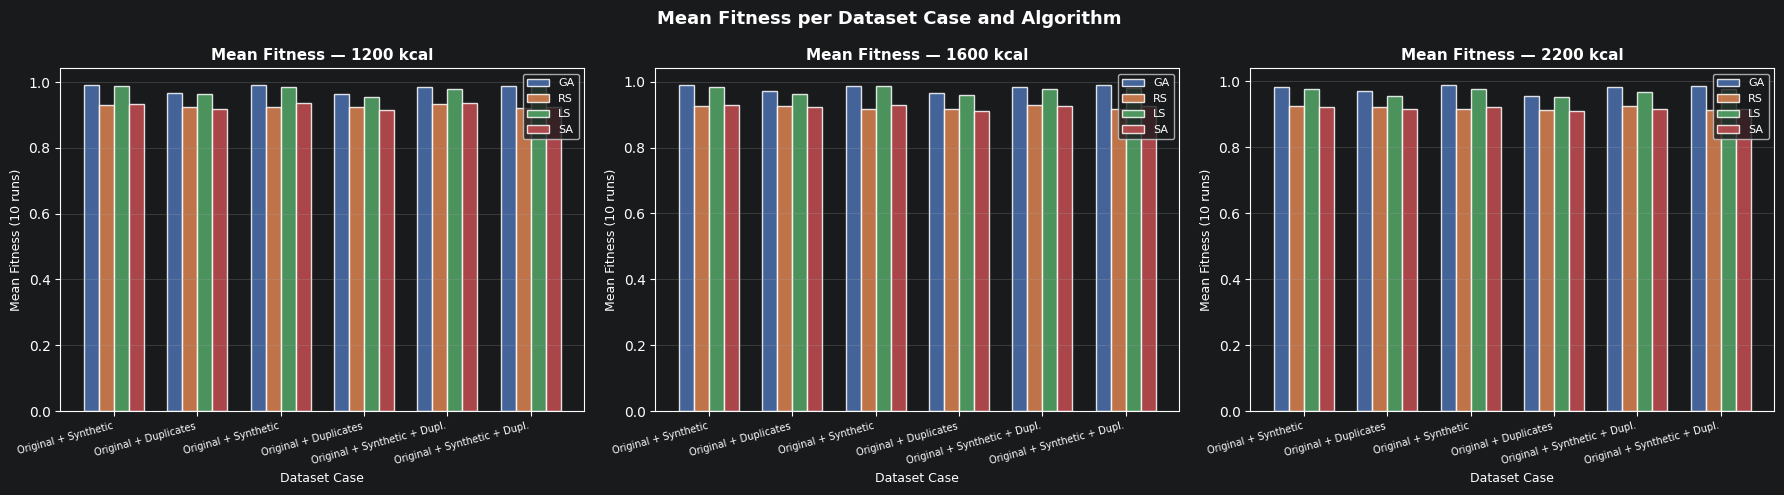

Saved: multi_case_bar_means.png


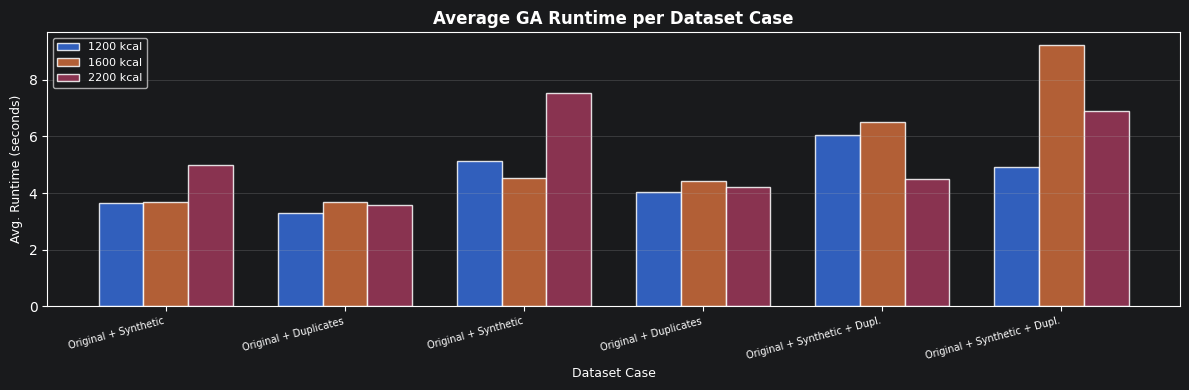

Saved: multi_case_ga_runtimes.png

Saved: multi_case_results_summary.csv
                                             Case  Target_kcal Algorithm  Mean_Fitness  Max_Fitness  Min_Fitness  Std_Fitness Avg_GA_Runtime_s
        Case 1 - 1000 rows (Original + Synthetic)         1200        GA      0.991986     0.994941     0.986354     0.002675           3.6531
        Case 1 - 1000 rows (Original + Synthetic)         1200        RS      0.929930     0.944329     0.918955     0.006977                 
        Case 1 - 1000 rows (Original + Synthetic)         1200        LS      0.988899     0.995508     0.982171     0.004517                 
        Case 1 - 1000 rows (Original + Synthetic)         1200        SA      0.933667     0.944656     0.923254     0.007397                 
        Case 1 - 1000 rows (Original + Synthetic)         1600        GA      0.990369     0.996449     0.979517     0.006140           3.6702
        Case 1 - 1000 rows (Original + Synthetic)         1600       

In [19]:
# ── Combined Report — run after all (or any subset of) case cells ────────────
# Works even if only some cases have been run; adapts automatically.

if not all_case_results:
    print('No results yet — run at least one Case cell first.')
else:
    available = list(all_case_results.keys())
    n_cases   = len(available)
    n_targets = len(EXP_TARGETS)
    print(f'Building report for {n_cases} case(s) ...\n')

    # ── 1. Printed summary table ──────────────────────────────────────────────
    print('\n' + '=' * 82)
    print('   SUMMARY REPORT')
    print('=' * 82)
    for case_label in available:
        cr = all_case_results[case_label]
        print(f"\n{'─'*82}")
        print(f'  {case_label}')
        print(f"{'─'*82}")
        hdr = f"  {'Target':<10} {'Algo':<6} {'Mean':>10} {'Max':>10} {'Min':>10} {'Std':>10}  {'GA Time':>9}"
        print(hdr)
        print('  ' + '-' * (len(hdr) - 2))
        for target in EXP_TARGETS:
            if target not in cr:
                continue
            for algo in ALGOS:
                s     = cr[target][algo]['stats']
                t_str = f"{cr[target]['GA']['avg_time']:.3f}s" if algo == 'GA' else ''
                print(f"  {str(target)+' kcal':<10} {algo:<6}"
                      f" {s['mean']:>10.6f} {s['max']:>10.6f} {s['min']:>10.6f} {s['std']:>10.6f}"
                      f"  {t_str:>9}")
            print()

    # ── 2. Box plots: one row per case, one column per target ─────────────────
    fig, axes = plt.subplots(n_cases, n_targets,
                              figsize=(5 * n_targets, 4 * n_cases), squeeze=False)
    for ri, case_label in enumerate(available):
        short = case_label.split('(')[0].strip()
        for ci, target in enumerate(EXP_TARGETS):
            ax   = axes[ri][ci]
            data = [all_case_results[case_label][target][a]['fitness'] for a in ALGOS]
            bp   = ax.boxplot(data, labels=ALGOS, patch_artist=True)
            for patch, algo in zip(bp['boxes'], ALGOS):
                patch.set_facecolor(ALGO_COLORS[algo])
                patch.set_alpha(0.75)
            ax.set_title(f'{short}  |  {target} kcal', fontsize=8, fontweight='bold')
            ax.set_ylabel('Fitness', fontsize=7)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=7)
    fig.suptitle(
        f'Fitness Distribution — GA vs RS vs LS vs SA\n{n_cases} Case(s) × 3 Calorie Targets',
        fontsize=13, fontweight='bold', y=1.002
    )
    plt.tight_layout()
    plt.savefig('multi_case_boxplots.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: multi_case_boxplots.png')

    # ── 3. Grouped bar chart: mean fitness by case, per target ────────────────
    case_short = [lbl.split('(')[1].rstrip(')') if '(' in lbl else lbl for lbl in available]
    x  = np.arange(n_cases)
    bw = 0.18
    fig2, axes2 = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5), squeeze=False)
    for ci, target in enumerate(EXP_TARGETS):
        ax = axes2[0][ci]
        for ai, algo in enumerate(ALGOS):
            means = [all_case_results[lbl][target][algo]['stats']['mean'] for lbl in available]
            ax.bar(x + ai * bw, means, bw, label=algo,
                   color=ALGO_COLORS[algo], alpha=0.85, edgecolor='white')
        ax.set_title(f'Mean Fitness — {target} kcal', fontsize=11, fontweight='bold')
        ax.set_xlabel('Dataset Case', fontsize=9)
        ax.set_ylabel('Mean Fitness (10 runs)', fontsize=9)
        ax.set_xticks(x + bw * 1.5)
        ax.set_xticklabels(case_short, fontsize=7, rotation=15, ha='right')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)
    fig2.suptitle('Mean Fitness per Dataset Case and Algorithm', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('multi_case_bar_means.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: multi_case_bar_means.png')

    # ── 4. GA runtime bar chart ───────────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(max(8, n_cases * 2), 4))
    bw3 = 0.25
    x3  = np.arange(n_cases)
    for ci, target in enumerate(EXP_TARGETS):
        runtimes = [all_case_times[lbl][target] for lbl in available]
        ax3.bar(x3 + ci * bw3, runtimes, bw3, label=f'{target} kcal', alpha=0.85, edgecolor='white')
    ax3.set_title('Average GA Runtime per Dataset Case', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Dataset Case', fontsize=9)
    ax3.set_ylabel('Avg. Runtime (seconds)', fontsize=9)
    ax3.set_xticks(x3 + bw3)
    ax3.set_xticklabels(case_short, fontsize=7, rotation=15, ha='right')
    ax3.legend(fontsize=8)
    ax3.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('multi_case_ga_runtimes.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: multi_case_ga_runtimes.png')

    # ── 5. Export flat CSV summary ────────────────────────────────────────────
    rows = []
    for case_label in available:
        for target in EXP_TARGETS:
            if target not in all_case_results[case_label]:
                continue
            for algo in ALGOS:
                s = all_case_results[case_label][target][algo]['stats']
                rows.append({
                    'Case':             case_label,
                    'Target_kcal':      target,
                    'Algorithm':        algo,
                    'Mean_Fitness':     round(s['mean'], 6),
                    'Max_Fitness':      round(s['max'],  6),
                    'Min_Fitness':      round(s['min'],  6),
                    'Std_Fitness':      round(s['std'],  6),
                    'Avg_GA_Runtime_s': round(all_case_results[case_label][target]['GA']['avg_time'], 4)
                                        if algo == 'GA' else '',
                })
    results_df = pd.DataFrame(rows)
    results_df.to_csv('multi_case_results_summary.csv', index=False)
    print('\nSaved: multi_case_results_summary.csv')
    print(results_df.to_string(index=False))
    print('\n✅ Report complete.')
